TESS columns: ['file', 'ticid', 'sector', 'cadence', 'best_period_days', 'max_power', 'amplitude_percent', 'peak1_period', 'peak2_period', 'peak3_period', 'peak4_period', 'peak5_period', 'peak1_power', 'peak2_power', 'peak3_power', 'peak4_power', 'peak5_power', 'power_pass', 'ref_period', 'period_agree', 'power_and_agree', 'double_dipper', 'true_period_d']
K2   columns: ['ra', 'dec', 'TIC', '2mass_id', 'KIC', 'Reinhold', 'McQuillan', 'Claytor ', 'Oelkers', 'Newton 2016', 'Newton 2018', 'Bouma', 'Walkowicz']

TESS rows after filter : 526
K2   rows after filter : 120
Merged rows (one per TESS sector): 526


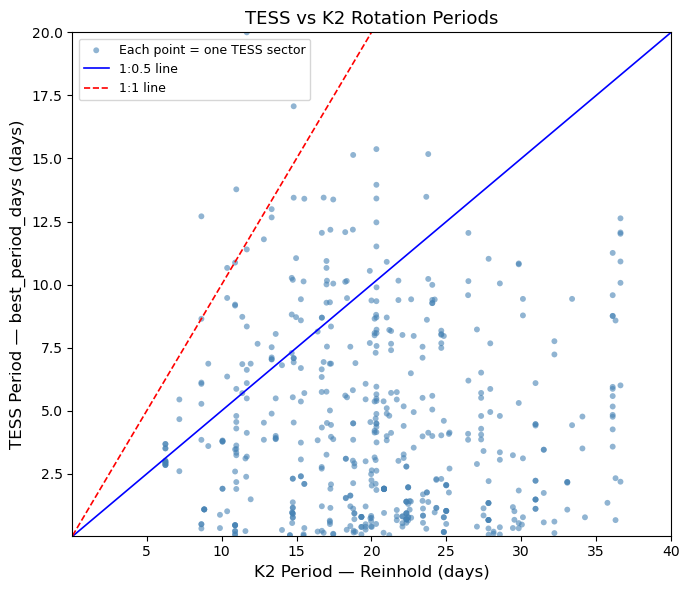

Plot saved to tess_vs_k2_periods.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Target TICIDs 
ticids = [
    9006668, 2760219, 343019899, 51637609, 100909102, 278892590, 38258419,
    436478932, 199444169, 228381868, 199671901, 434094657, 38337202, 201177276,
    291685334, 9030119, 38355468, 69747919, 12821302, 49592509, 8918021,
    402026209, 398572544, 146364192, 437704321, 422618449, 455784423, 188509935,
    423610130, 376637093, 139285832, 183532609, 114749636, 250111245, 121490076,
    250956593, 188507501, 237320326, 39926974, 204376737, 441462736, 4610830,
    267215820, 250979498, 288246496, 183537452, 238176110, 201175570, 184240683,
    301258470, 169765334, 439842788, 402287746, 262715204, 427761355, 248608315,
    146799150, 317597583, 38354061, 333473672, 234994474, 91051152, 262662119,
    36592530, 49679172, 301132473, 266980320, 183985250, 39928614, 204317710,
    12785571, 346338552, 431701493, 188570092, 12770870, 49709169, 188876052,
    8963531, 305048087, 288144647, 240766850, 250977648, 145750719, 145752628,
    9030096, 76923707, 9054633, 301289516, 77044471, 49735922, 89020549,
    422487869, 317060587, 301288279, 301235044, 470171739, 437703489, 176899385,
    39936432, 404243877, 279046938, 77031414, 62483237, 291751373, 251018878,
    206284139, 283722336, 210083929, 402314147, 250996363, 367858035, 410153553,
    12822545, 224225541, 427685831, 188570847, 144065872, 403224672, 224245334,
    410214986,
]

# ── 2. Load data 
tess_path = "/Users/suyuxin/downloads/SPOC_ls_results_with_flags.csv"
k2_path   = "/Users/suyuxin/downloads/updated_catalogperiods(in).csv"

tess_df = pd.read_csv(tess_path)
k2_df   = pd.read_csv(k2_path)

# ── 3. Normalise the TIC/ID column names 
# Print available columns so you can adjust if needed
print("TESS columns:", tess_df.columns.tolist())
print("K2   columns:", k2_df.columns.tolist())

# Best-guess column names — adjust these two strings if your CSVs differ
TESS_ID_COL   = "ticid"          # e.g. "ticid", "TIC", "TICID", "tic_id" …
TESS_PER_COL  = "best_period_days"
K2_ID_COL     = "TIC"          # e.g. "TICID", "TIC", "tic_id" …
K2_PER_COL    = "Reinhold"

# Coerce ID columns to int for reliable matching
tess_df[TESS_ID_COL] = pd.to_numeric(tess_df[TESS_ID_COL], errors="coerce").astype("Int64")
k2_df[K2_ID_COL]     = pd.to_numeric(k2_df[K2_ID_COL],     errors="coerce").astype("Int64")

# ── 4. Filter to target TICIDs
tess_filtered = tess_df[tess_df[TESS_ID_COL].isin(ticids)][
    [TESS_ID_COL, TESS_PER_COL]
].copy()

k2_filtered = k2_df[k2_df[K2_ID_COL].isin(ticids)][
    [K2_ID_COL, K2_PER_COL]
].copy()

print(f"\nTESS rows after filter : {len(tess_filtered)}")
print(f"K2   rows after filter : {len(k2_filtered)}")

# ── 5. Merge (many TESS rows per TICID × one K2 row per TICID)
merged = tess_filtered.merge(
    k2_filtered,
    left_on=TESS_ID_COL,
    right_on=K2_ID_COL,
    how="inner",
)
merged = merged.dropna(subset=[TESS_PER_COL, K2_PER_COL])
print(f"Merged rows (one per TESS sector): {len(merged)}")

# ── 6. Plot 
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    merged[K2_PER_COL],
    merged[TESS_PER_COL],
    s=18,
    alpha=0.6,
    edgecolors="none",
    color="steelblue",
    label="Each point = one TESS sector",
)

# 1:1 reference line
lim_min = min(merged[K2_PER_COL].min(), merged[TESS_PER_COL].min()) * 0.9
lim_max = max(merged[K2_PER_COL].max(), merged[TESS_PER_COL].max()) * 1.1
ax.plot([lim_min, lim_max], [0.5*lim_min, 0.5*lim_max],
        color="blue", lw=1.2, label="1:0.5 line")
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        "r--", lw=1.2, label="1:1 line")

ax.set_xlabel("K2 Period — Reinhold (days)", fontsize=12)
ax.set_ylabel("TESS Period — best_period_days (days)", fontsize=12)
ax.set_title("TESS vs K2 Rotation Periods", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(lim_min, 40)
ax.set_ylim(lim_min, 20)

plt.tight_layout()
plt.savefig("tess_vs_k2_periods.png", dpi=150)
plt.show()
print("Plot saved to tess_vs_k2_periods.png")

TESS columns: ['ticid', 'periods']
K2   columns: ['ra', 'dec', 'TIC', '2mass_id', 'KIC', 'Reinhold', 'McQuillan', 'Claytor ', 'Oelkers', 'Newton 2016', 'Newton 2018', 'Bouma', 'Walkowicz']

TESS rows after filter : 48
K2   rows after filter : 120
Merged rows (one per TESS sector): 48


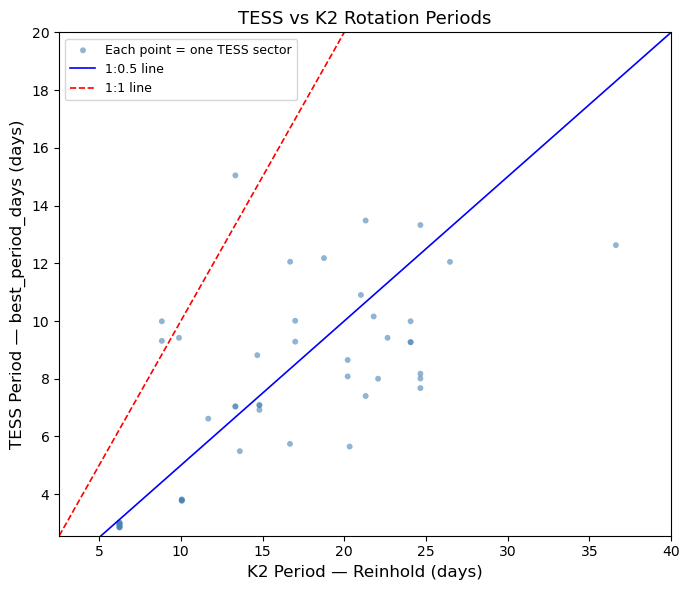

Plot saved to tess_vs_k2_periods.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Target TICIDs ─────────────────────────────────────────────────────────
ticids = [
    9006668, 2760219, 343019899, 51637609, 100909102, 278892590, 38258419,
    436478932, 199444169, 228381868, 199671901, 434094657, 38337202, 201177276,
    291685334, 9030119, 38355468, 69747919, 12821302, 49592509, 8918021,
    402026209, 398572544, 146364192, 437704321, 422618449, 455784423, 188509935,
    423610130, 376637093, 139285832, 183532609, 114749636, 250111245, 121490076,
    250956593, 188507501, 237320326, 39926974, 204376737, 441462736, 4610830,
    267215820, 250979498, 288246496, 183537452, 238176110, 201175570, 184240683,
    301258470, 169765334, 439842788, 402287746, 262715204, 427761355, 248608315,
    146799150, 317597583, 38354061, 333473672, 234994474, 91051152, 262662119,
    36592530, 49679172, 301132473, 266980320, 183985250, 39928614, 204317710,
    12785571, 346338552, 431701493, 188570092, 12770870, 49709169, 188876052,
    8963531, 305048087, 288144647, 240766850, 250977648, 145750719, 145752628,
    9030096, 76923707, 9054633, 301289516, 77044471, 49735922, 89020549,
    422487869, 317060587, 301288279, 301235044, 470171739, 437703489, 176899385,
    39936432, 404243877, 279046938, 77031414, 62483237, 291751373, 251018878,
    206284139, 283722336, 210083929, 402314147, 250996363, 367858035, 410153553,
    12822545, 224225541, 427685831, 188570847, 144065872, 403224672, 224245334,
    410214986,
]

# ── 2. Load data 
tess_path = "/Users/suyuxin/downloads/FINAL_TRUE_TESS_Rotation_Period_Sample.csv"
k2_path   = "/Users/suyuxin/downloads/updated_catalogperiods(in).csv"

tess_df = pd.read_csv(tess_path)
k2_df   = pd.read_csv(k2_path)

# ── 3. Normalise the TIC/ID column names ─────────────────────────────────────
# Print available columns so you can adjust if needed
print("TESS columns:", tess_df.columns.tolist())
print("K2   columns:", k2_df.columns.tolist())

# Best-guess column names — adjust these two strings if your CSVs differ
TESS_ID_COL   = "ticid"          # e.g. "ticid", "TIC", "TICID", "tic_id" …
TESS_PER_COL  = "periods"
K2_ID_COL     = "TIC"          # e.g. "TICID", "TIC", "tic_id" …
K2_PER_COL    = "Reinhold"

# Coerce ID columns to int for reliable matching
tess_df[TESS_ID_COL] = pd.to_numeric(tess_df[TESS_ID_COL], errors="coerce").astype("Int64")
k2_df[K2_ID_COL]     = pd.to_numeric(k2_df[K2_ID_COL],     errors="coerce").astype("Int64")

# ── 4. Filter to target TICIDs
tess_filtered = tess_df[tess_df[TESS_ID_COL].isin(ticids)][
    [TESS_ID_COL, TESS_PER_COL]
].copy()

k2_filtered = k2_df[k2_df[K2_ID_COL].isin(ticids)][
    [K2_ID_COL, K2_PER_COL]
].copy()

print(f"\nTESS rows after filter : {len(tess_filtered)}")
print(f"K2   rows after filter : {len(k2_filtered)}")

# ── 5. Merge (many TESS rows per TICID × one K2 row per TICID)
merged = tess_filtered.merge(
    k2_filtered,
    left_on=TESS_ID_COL,
    right_on=K2_ID_COL,
    how="inner",
)
merged = merged.dropna(subset=[TESS_PER_COL, K2_PER_COL])
print(f"Merged rows (one per TESS sector): {len(merged)}")

# ── 6. Plot 
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    merged[K2_PER_COL],
    merged[TESS_PER_COL],
    s=18,
    alpha=0.6,
    edgecolors="none",
    color="steelblue",
    label="Each point = one TESS sector",
)

# 1:1 reference line
lim_min = min(merged[K2_PER_COL].min(), merged[TESS_PER_COL].min()) * 0.9
lim_max = max(merged[K2_PER_COL].max(), merged[TESS_PER_COL].max()) * 1.1
ax.plot([lim_min, lim_max], [0.5*lim_min, 0.5*lim_max],
        color="blue", lw=1.2, label="1:0.5 line")
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        "r--", lw=1.2, label="1:1 line")

ax.set_xlabel("K2 Period — Reinhold (days)", fontsize=12)
ax.set_ylabel("TESS Period — best_period_days (days)", fontsize=12)
ax.set_title("TESS vs K2 Rotation Periods", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(lim_min, 40)
ax.set_ylim(lim_min, 20)

plt.tight_layout()
plt.savefig("tess_vs_k2_periods.png", dpi=150)
plt.show()
print("Plot saved to tess_vs_k2_periods.png")